## WORKSHOP - 5: License Plate Detection using OpenCV and Haar Cascade Classifier 

### NAME : A PRAVEEN KISHORE
### REG. NO : 212225220074
### DATE : 07/09/26

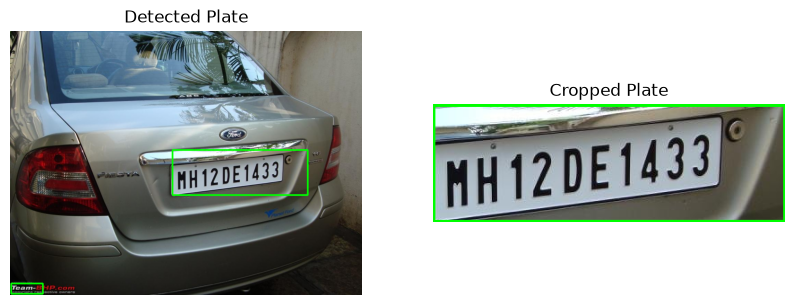

In [8]:
import cv2
import matplotlib.pyplot as plt

# Put your full path to the files here (keep the 'r' in front):
plate_cascade = cv2.CascadeClassifier("haarcascade_russian_plate_number.xml")
img = cv2.imread("car.jpg")

# Check if image loaded properly
if img is None:
    raise FileNotFoundError("Image still not found! Check the path above.")

# 1. Preprocessing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. Detection
plates = plate_cascade.detectMultiScale(blurred, scaleFactor=1.1, minNeighbors=4)

# 3. Draw box & Crop
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cropped_plate = None

for (x, y, w, h) in plates:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cropped_plate = img_rgb[y:y + h, x:x + w]
    cv2.imwrite("plate_crop.png", cv2.cvtColor(cropped_plate, cv2.COLOR_RGB2BGR))

# 4. Show output
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Detected Plate")
plt.imshow(img_rgb)
plt.axis("off")

if cropped_plate is not None:
    plt.subplot(1, 2, 2)
    plt.title("Cropped Plate")
    plt.imshow(cropped_plate)
    plt.axis("off")

plt.show()